[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/01.quantum-foundations/03.gates-measurement-and-entanglement/day06_derived_03_01_01_to_03_01_03_two_qubit_hadamard_comparison_lab.ipynb)


# 3-1. Two-Qubit Hadamard Superposition Practice


이 노트북은 `3-1-1.py`, `3-1-2.py`, `3-1-3.py`를 하나의 작업 단위로 정리한 버전입니다.

**확인한 원본 코드**
- `3-1-1.py`: 2-qubit 회로를 그대로 측정해 `00`만 나오는지 확인합니다.
- `3-1-2.py`: 첫 번째 qubit에 Hadamard gate를 적용해 `00`과 `01` 계열이 반반 나오는지 봅니다.
- `3-1-3.py`: 두 qubit 모두 Hadamard gate를 적용해 `00`, `01`, `10`, `11`이 거의 균등하게 나오는지 확인합니다.

**학습 목표**
- `H` gate가 한 qubit의 측정 분포를 어떻게 바꾸는지 확인합니다.
- 두 qubit에 각각 `H` gate를 적용하면 가능한 bitstring 수가 어떻게 늘어나는지 관찰합니다.
- 같은 실행 구조를 사용해 여러 회로를 비교하는 방법을 익힙니다.


## Outline

1. 원본 파일과 실습 목적 확인
2. Qiskit 실행 준비
3. 세 가지 2-qubit 회로 구성
4. 측정 counts와 확률 비교
5. 결과 시각화
6. 연습 문제


## 1. Source Map

세 파일의 차이는 Hadamard gate를 어느 qubit에 적용하는지입니다.


In [1]:
SOURCE_CASES = {
    "3-1-1.py": "measure |00> without Hadamard gates",
    "3-1-2.py": "apply H to qubit 0, then measure",
    "3-1-3.py": "apply H to qubits 0 and 1, then measure",
}

for source_name, description in SOURCE_CASES.items():
    print(f"{source_name}: {description}")


3-1-1.py: measure |00> without Hadamard gates
3-1-2.py: apply H to qubit 0, then measure
3-1-3.py: apply H to qubits 0 and 1, then measure


## 2. Imports

이 실습은 Qiskit과 Qiskit Aer가 필요합니다. 새 Colab 런타임에서 import가 실패하면 설치 줄의 주석을 해제해 한 번 실행한 뒤, 런타임을 다시 시작하고 이어서 실행합니다.


In [2]:
# If Qiskit is missing in a fresh Colab runtime, uncomment and run once.
# %pip install -q qiskit qiskit-aer

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

SHOTS = 1000
SEED_SIMULATOR = 3101


## 3. Build the Three Circuits

Qiskit은 오른쪽 bit가 qubit 0의 측정값으로 표시됩니다. 따라서 `h(0)`을 적용하면 출력 문자열의 오른쪽 자리가 흔들립니다.


In [3]:
def run_counts(circuit: QuantumCircuit, shots: int, seed: int) -> dict[str, int]:
    simulator = AerSimulator(seed_simulator=seed)
    job = simulator.run(circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()
    return {state: int(count) for state, count in counts.items()}


def normalize_counts(counts: dict[str, int], shots: int) -> dict[str, float]:
    return {state: count / shots for state, count in sorted(counts.items())}


In [4]:
circuit_00 = QuantumCircuit(2)
circuit_00.measure_all()

circuit_h0 = QuantumCircuit(2)
circuit_h0.h(0)
circuit_h0.measure_all()

circuit_h01 = QuantumCircuit(2)
circuit_h01.h(0)
circuit_h01.h(1)
circuit_h01.measure_all()

experiments = [
    ("3-1-1.py", "|00>", circuit_00),
    ("3-1-2.py", "H on q0", circuit_h0),
    ("3-1-3.py", "H on q0 and q1", circuit_h01),
]

for source_name, label, circuit in experiments:
    print()
    print(f"{source_name} - {label}")
    print(circuit.draw(output="text"))



3-1-1.py - |00>
         ░ ┌─┐   
   q_0: ─░─┤M├───
         ░ └╥┘┌─┐
   q_1: ─░──╫─┤M├
         ░  ║ └╥┘
meas: 2/════╩══╩═
            0  1 

3-1-2.py - H on q0
        ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├─░─┤M├───
        └───┘ ░ └╥┘┌─┐
   q_1: ──────░──╫─┤M├
              ░  ║ └╥┘
meas: 2/═════════╩══╩═
                 0  1 

3-1-3.py - H on q0 and q1
        ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├─░─┤M├───
        ├───┤ ░ └╥┘┌─┐
   q_1: ┤ H ├─░──╫─┤M├
        └───┘ ░  ║ └╥┘
meas: 2/═════════╩══╩═
                 0  1 


## 4. Run and Compare Counts

각 회로를 `shots=1000`으로 실행합니다. 확률값은 counts를 전체 shots로 나누어 계산합니다.


In [5]:
counts_by_label = {
    label: run_counts(circuit, SHOTS, SEED_SIMULATOR + index)
    for index, (_, label, circuit) in enumerate(experiments)
}
probabilities_by_label = {
    label: normalize_counts(counts, SHOTS)
    for label, counts in counts_by_label.items()
}

for source_name, label, _ in experiments:
    print(f"{source_name} ({label})")
    print("counts:", counts_by_label[label])
    print("probabilities:", probabilities_by_label[label])


3-1-1.py (|00>)
counts: {'00': 1000}
probabilities: {'00': 1.0}
3-1-2.py (H on q0)
counts: {'01': 484, '00': 516}
probabilities: {'00': 0.516, '01': 0.484}
3-1-3.py (H on q0 and q1)
counts: {'01': 247, '11': 253, '10': 239, '00': 261}
probabilities: {'00': 0.261, '01': 0.247, '10': 0.239, '11': 0.253}


## 5. Visualize the Result

Hadamard gate를 적용한 qubit 수가 늘어날수록 측정 가능한 bitstring의 종류도 늘어납니다.


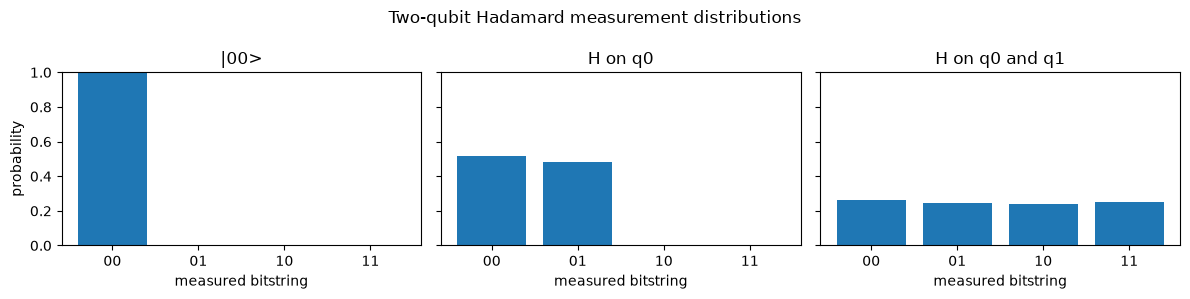

In [6]:
states = ["00", "01", "10", "11"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for axis, (_, label, _) in zip(axes, experiments):
    probabilities = probabilities_by_label[label]
    axis.bar(states, [probabilities.get(state, 0.0) for state in states])
    axis.set_title(label)
    axis.set_ylim(0, 1)
    axis.set_xlabel("measured bitstring")

axes[0].set_ylabel("probability")
fig.suptitle("Two-qubit Hadamard measurement distributions")
fig.tight_layout()
plt.show()


## 6. Exercise

두 qubit 중 qubit 1에만 Hadamard gate를 적용해 보세요. `h(0)`과 `h(1)`의 결과 bitstring 위치가 어떻게 다른지 비교합니다.


In [7]:
exercise_circuit = QuantumCircuit(2)
exercise_circuit.h(1)
exercise_circuit.measure_all()

exercise_counts = run_counts(exercise_circuit, SHOTS, SEED_SIMULATOR + 99)
exercise_probabilities = normalize_counts(exercise_counts, SHOTS)

print(exercise_circuit.draw(output="text"))
print(exercise_counts)
print(exercise_probabilities)


              ░ ┌─┐   
   q_0: ──────░─┤M├───
        ┌───┐ ░ └╥┘┌─┐
   q_1: ┤ H ├─░──╫─┤M├
        └───┘ ░  ║ └╥┘
meas: 2/═════════╩══╩═
                 0  1 
{'00': 493, '10': 507}
{'00': 0.493, '10': 0.507}


## Pitfall and Extension

**주의할 점**: Qiskit의 bitstring 표기는 qubit 번호와 왼쪽-오른쪽 위치가 직관과 다르게 느껴질 수 있습니다. `h(0)`과 `h(1)`을 바꾸어 실행하면서 어느 자리가 바뀌는지 직접 확인하세요.

**확장 실습**: 두 qubit 회로에 `x(0)` 또는 `x(1)`을 추가해 초기 bitstring이 어떻게 바뀌는지 비교해 보세요.
